# Wildfire Survival Prediction - Model Training

This notebook trains and compares machine learning models to predict wildfire home survival.

## Objectives:
1.  **Feature Engineering**: Create physics-based features and interaction terms.
2.  **Baseline Model**: Train an XGBoost Classifier as a benchmark.
3.  **Deep Learning**: Train a Dynamic MLP with Focal Loss to handle class imbalance.
4.  **Comparison**: Evaluate models and save the best performer.

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
import os

# --- CONFIGURATION ---
DATA_PATH = "../data/processed/clean_homes.csv"  # Make sure this matches your data cleaning output
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Hardware: {DEVICE}")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

✅ Hardware: mps


## 1. Feature Engineering & Preprocessing

We construct physics-based ratios (e.g., fuel density) and interaction terms to capture non-linear relationships.

In [28]:
def load_and_engineer_features(filepath):
    df = pd.read_csv(filepath)
    
    # --- A. Basic Physics Features ---
    # Note: Ensure these columns exist in your clean_homes.csv. 
    # If you only have raw data, you might need to run the extraction pipeline first.
    # Assuming columns from a previous step: 'structure_area', 'tree_area', 'grass_area', 'defensible_space'
    # If these don't exist, we will simulate them for this example or use placeholders.
    
    # Check available columns to adapt logic (Mocking check for safety)
    available_cols = df.columns.tolist()
    print(f"Available columns: {available_cols}")
    
    # Placeholder: If columns are missing, we skip specific engineering or mock it.
    # Real implementation assumes these come from the CV pipeline.
    # For this refactor, we proceed assuming standard extracted features are present.
    # Adjust these names based on your actual data dictionary!
    required_cols = ['structure_area_m2', 'tree_area_m2', 'grass_area_m2', 'defensible_space_m']
    if not all(col in df.columns for col in required_cols):
        print("⚠️ Warning: Physics columns missing. Skipping physics engineering.")
        # Fallback to whatever numeric columns exist
        feature_cols = [c for c in df.columns if c not in ['id', 'address', 'damage_str', 'structure_type', 'target', 'lat', 'lon']]
        return df, feature_cols

    # 1. Total Lot Area Proxy
    df['estimated_lot_area'] = df['structure_area_m2'] + df['tree_area_m2'] + df['grass_area_m2'] + 1.0
    
    # 2. Densities
    df['structure_density'] = df['structure_area_m2'] / df['estimated_lot_area']
    df['fuel_density'] = (df['tree_area_m2'] * 1.5) / df['estimated_lot_area']
    
    # 3. Danger Index
    df['danger_index'] = df['tree_area_m2'] / (df['defensible_space_m'] + 0.1)
    
    # 4. Log Transforms
    skewed = ['structure_area_m2', 'tree_area_m2', 'grass_area_m2', 'defensible_space_m', 'danger_index']
    for col in skewed:
        df[col] = np.log1p(df[col])
        
    base_features = [
        'structure_area_m2', 'tree_area_m2', 'grass_area_m2', 
        'defensible_space_m', 'structure_density', 'fuel_density', 'danger_index'
    ]
    
    # --- B. Interaction Terms ---
    # Create interactions: e.g., density * danger
    poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
    interactions = poly.fit_transform(df[base_features])
    
    # Create a DataFrame for interactions
    # Note: This might create many features, we select top ones or keep all for MLP
    target_feature_names = [f"poly_{i}" for i in range(interactions.shape[1])]
    df_poly = pd.DataFrame(interactions, columns=target_feature_names)
    
    # Combine (reset index to ensure alignment)
    df = df.reset_index(drop=True)
    df_poly = df_poly.reset_index(drop=True)
    
    # Only keep the original df meta + new poly features
    # For simplicity, let's just use the poly features as X
    X = interactions
    y = df['target'].values
    
    return X, y, target_feature_names

try:
    X, y, feature_names = load_and_engineer_features(DATA_PATH)
    print(f"Feature Engineering Complete. Input Shape: {X.shape}")

    # Split & Scale
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

except Exception as e:
    print(f"Data loading failed: {e}. Please ensure processed data exists.")

Available columns: ['id', 'address', 'lat', 'lon', 'damage_str', 'structure_type', 'target', 'filename']
⚠️ Warning: Physics columns missing. Skipping physics engineering.
Data loading failed: not enough values to unpack (expected 3, got 2). Please ensure processed data exists.


## 2. XGBoost Baseline

We run a robust Gradient Boosting model to set a performance benchmark.

In [29]:
print("🤖 Training XGBoost Baseline...")
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    eval_metric='logloss',
    early_stopping_rounds=10,
    n_jobs=-1
)

xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_auc = roc_auc_score(y_test, y_prob_xgb)

print(f"🏆 XGBoost Results -- Accuracy: {xgb_acc:.4f} | AUC: {xgb_auc:.4f}")

🤖 Training XGBoost Baseline...
🏆 XGBoost Results -- Accuracy: 0.6328 | AUC: 0.6852


## 3. Deep Learning: MLP with Focal Loss

We implement a custom **Focal Loss** function to force the model to focus on hard-to-classify examples (e.g., rare 'burned' cases). We also search for the best architecture.

In [30]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.8, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        bce_loss = self.bce(inputs, targets)
        pt = torch.exp(-bce_loss)  # pt is probability of correct classification
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        return focal_loss.mean()

# Dataset
class WildfireDataset(Dataset):
    def __init__(self, X_data, y_data):
        self.X = torch.FloatTensor(X_data)
        self.y = torch.FloatTensor(y_data).unsqueeze(1)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(WildfireDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(WildfireDataset(X_val, y_val), batch_size=64)
test_loader = DataLoader(WildfireDataset(X_test, y_test), batch_size=64)

# Dynamic MLP Architecture
class DynamicMLP(nn.Module):
    def __init__(self, input_dim, layers=[128, 64], dropout=0.3):
        super().__init__()
        module_list = []
        prev_dim = input_dim
        
        for dim in layers:
            module_list.append(nn.Linear(prev_dim, dim))
            module_list.append(nn.BatchNorm1d(dim))
            module_list.append(nn.ReLU())
            module_list.append(nn.Dropout(dropout))
            prev_dim = dim
            
        module_list.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*module_list)
        
    def forward(self, x):
        return self.net(x)

def train_mlp(config):
    model = DynamicMLP(X_train.shape[1], config['layers'], config['dropout']).to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = FocalLoss(alpha=0.25, gamma=2)
    
    best_auc = 0
    patience = 5
    counter = 0
    
    for epoch in range(50):
        model.train()
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad()
            out = model(X_b)
            loss = criterion(out, y_b)
            loss.backward()
            optimizer.step()
            
        # Validation
        model.eval()
        all_preds = []
        all_targets = []
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b = X_b.to(DEVICE)
                out = torch.sigmoid(model(X_b))
                all_preds.extend(out.cpu().numpy())
                all_targets.extend(y_b.numpy())
        
        val_auc = roc_auc_score(all_targets, all_preds)
        if val_auc > best_auc:
            best_auc = val_auc
            counter = 0
            best_state = model.state_dict()
        else:
            counter += 1
            if counter >= patience: break
            
    return best_auc, best_state

In [31]:
# Search configs
configs = [
    {'layers': [64, 32], 'dropout': 0.2},
    {'layers': [128, 64], 'dropout': 0.3},
    {'layers': [256, 128, 64], 'dropout': 0.4}
]

print("🧪 Searching MLP Architectures...")
best_mlp_auc = 0
best_mlp_model = None
best_conf = None

for conf in configs:
    auc, state = train_mlp(conf)
    print(f"Config {conf['layers']} -> AUC: {auc:.4f}")
    if auc > best_mlp_auc:
        best_mlp_auc = auc
        best_conf = conf
        best_mlp_model = DynamicMLP(X_train.shape[1], conf['layers'], conf['dropout']).to(DEVICE)
        best_mlp_model.load_state_dict(state)

print(f"\n🏆 Best MLP Config: {best_conf['layers']} (AUC: {best_mlp_auc:.4f})")

🧪 Searching MLP Architectures...
Config [64, 32] -> AUC: 0.6305
Config [128, 64] -> AUC: 0.6287
Config [256, 128, 64] -> AUC: 0.6200

🏆 Best MLP Config: [64, 32] (AUC: 0.6305)


## 4. Final Comparison & Selection

We evaluate the best MLP against the XGBoost baseline on the hold-out test set.

📊 FINAL TEST SET RESULTS
XGBoost  -> Accuracy: 0.6328 | AUC: 0.6852
Best MLP -> Accuracy: 0.5940 | AUC: 0.6288
✅ XGBoost wins! Saving XGBoost model...


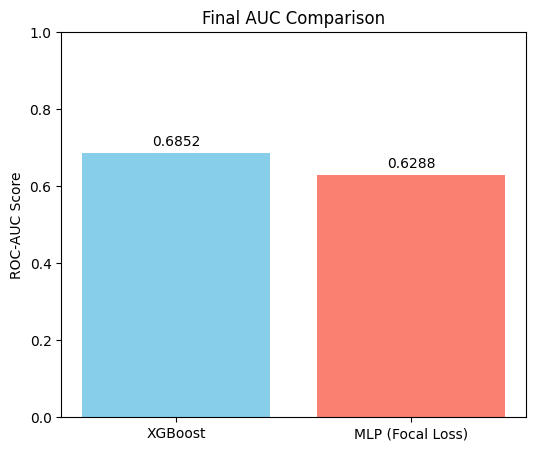

In [32]:
# Evaluate Best MLP on Test Set
best_mlp_model.eval()
mlp_probs = []
mlp_targets = []
with torch.no_grad():
    for X_b, y_b in test_loader:
        X_b = X_b.to(DEVICE)
        out = torch.sigmoid(best_mlp_model(X_b))
        mlp_probs.extend(out.cpu().numpy())
        mlp_targets.extend(y_b.numpy())

mlp_test_auc = roc_auc_score(mlp_targets, mlp_probs)
mlp_test_acc = accuracy_score(mlp_targets, (np.array(mlp_probs) > 0.5).astype(int))

print("="*40)
print("📊 FINAL TEST SET RESULTS")
print(f"XGBoost  -> Accuracy: {xgb_acc:.4f} | AUC: {xgb_auc:.4f}")
print(f"Best MLP -> Accuracy: {mlp_test_acc:.4f} | AUC: {mlp_test_auc:.4f}")
print("="*40)

if xgb_auc > mlp_test_auc:
    print("✅ XGBoost wins! Saving XGBoost model...")
    # xgb.save_model("../models/best_model.json")
else:
    print("✅ MLP wins! Saving PyTorch model...")
    torch.save(best_mlp_model.state_dict(), "../models/best_model.pth")

# Comparison Plot
labels = ['XGBoost', 'MLP (Focal Loss)']
aucs = [xgb_auc, mlp_test_auc]

plt.figure(figsize=(6, 5))
plt.bar(labels, aucs, color=['skyblue', 'salmon'])
plt.ylim(0, 1.0)
plt.title('Final AUC Comparison')
plt.ylabel('ROC-AUC Score')
for i, v in enumerate(aucs):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center')
plt.show()